# **Rey evitando piezas rivales**
Integrantes:

*   Sonia Aylin Castro Cedeño
*   Gerardo Govany Padiula miranda
*   Pedro Fernández Jiménez

URL: https://github.com/GerryPad/IA


# **Objetivo**

Nuestro problema consiste en tener un tablero de ajedrez de 16x16 con varias piezas rivales: alfiles, caballos y torres; un rey colocado en alguna casilla libre (que no esté en jaque) busca encontrar un camino para llegar hasta otra casilla “meta”. El rey tiene sus movimientos ortogonales y diagonales, una casilla por movimiento; el rey no puede posicionarse en ninguna casilla amenazada, las piezas rivales tienen posiciones estáticas (no mueven) y el rey no puede capturar.

---

La casilla marcada con GO! es la salida, la casilla marcada con ✔ es la meta y las piezas azules representan a los enemigos. El objetivo es que el rey vaya de GO! a ✔ sin ser atacado.


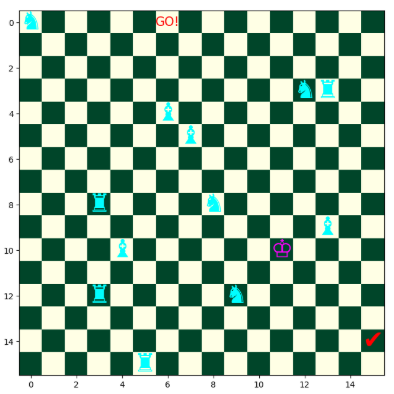

# Tamaño de la Búsqueda
El factor de ramificación b para este problema se determina calculando el promedio de estados sucesores que puede generar cada estado. Como disponemos de un tablero de 16x16, el total de casillas en las que puede ubicarse el rey es 256:


1.   Las casillas internas pertenecientes al cuadrado de 14x14 tienen cada una la posibilidad de generar hasta 8 estados sucesores; 14x14x8=1568.
2. Las casillas laterales del tablero, exceptuando las esquinas, tienen la posibilidad de generar hasta 5 estados cada una; 14x4x5=280.
3. Las casillas de las esquinas solo pueden generar 3 estados; 4x3=12


Partiendo de esto, entonces el promedio de estados generados por casilla es:
*(1568+280+12)/256=7.265625*


El valor de profundidad de solución d, dependerá de la complejidad de la instancia, incluyendo cantidad de piezas rivales, tipo de pieza rival (una torre suele ser más problemática que un caballo) y distancia de la casilla meta.

Para proponer un valor **d**, consideraremos las 3 instancias solicitadas; cada caso tendrá un número mínimo de movimientos para resolverse (determinado por la heurística propuesta) y para ajustar el valor consideraremos un valor de congestión c, de acuerdo al número de piezas rivales que podemos encontrarnos:

*   Fácil: origen=(8,4), destino=(1,0), pocas piezas rivales, c=1.2
d=max(|8-1|,|4-0|)*c[8,9]
*   Medio: origen=(6,0), destino=(15,14), algunas piezas rivales, c=1.5
d=max(|6-8|,|4-14|)*c15
* Difícil: origen=(1,4), destino=(14,11), algunas piezas rivales, c=1.8
d=max(|1-14|,|4-11|)*c[23,24]



In [ ]:
#Importacion de librerias
import urllib.request #Para descargar recursos remotos
import importlib.util #Carga e importacion de modulos
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

#Fork del repositorio original "baile"
url = "https://raw.githubusercontent.com/GerryPad/IA/refs/heads/master/src/SimpleSearch.py"

urllib.request.urlretrieve(url, "SimpleSearch.py")

#Importamos los algoritmos de busqueda
import SimpleSearch as sp

import math
import time #Para tomar el tiempo de cada algoritmo
from IPython.display import clear_output #Para las animaciones del tablero
tam_tab = 16

In [ ]:
"""
Funcion que determina si una casilla se encuentra amenazada por una pieza rival.
Recibe una posible casilla (cx, cy) y proyecta los movimientos de las piezas rivales para determinar si
se encuentra bajo amenaza; también considera si la pieza rival esta tapada por otra.
"""
def esta_amenazada(cx, cy, ocupadas):
  direcciones_ortogonales = [(1, 0), (-1, 0), (0, 1), (0, -1)] #Movimientos de torre
  direcciones_diagonales = [(1, 1), (1, -1), (-1, 1), (-1, -1)] #Movientos de alfil
  saltos_caballo = [(2, 1), (2, -1), (-2, 1), (-2, -1),(1, 2), (1, -2), (-1, 2), (-1, -2)]

  #Comprobar si la casilla coincide con el salto de algun caballo
  for dx, dy in saltos_caballo:
      if (cx + dx, cy + dy) in caballos:
          return True

  #Proyectamos un rayo en cada horizontal y vertical hasta el limite del tablero
  for dx, dy in direcciones_ortogonales:
      act_x, act_y = cx + dx, cy + dy
      while 0 <= act_x < tam_tab and 0 <= act_y < tam_tab:
          #Si el primer obstaculo es una torre, la casilla esta amenazada
          if (act_x, act_y) in ocupadas:
              if (act_x, act_y) in torres:
                  return True
              break #Cualquier otra pieza en esta direccion bloquea ataques de torre
          act_x += dx
          act_y += dy

  #Proyectamos rayo en diagonales hasta el limite del tablero...
  for dx, dy in direcciones_diagonales:
      act_x, act_y = cx + dx, cy + dy
      while 0 <= act_x < tam_tab and 0 <= act_y < tam_tab:
        #Si el primer obstaculo es una alfil, la casilla esta amenazada
          if (act_x, act_y) in ocupadas:
              if (act_x, act_y) in alfiles:
                  return True
              break #Cualquier otra pieza en esta direccion bloquea ataques de alfil
          act_x += dx
          act_y += dy

  return False #Si no hay amenazas

In [ ]:
#Funcion para filtrar estados sucesores; no estan permitidas las capturas del rey ni las casillas en jaque.
def descartar_amenazas(sucesores):
    ocupadas = set(alfiles + torres + caballos)

    sucesores_seguros = []

    for nodo in sucesores:
      #Si la casilla propuesta esta ocupada, no se considera para los sucesores
      if nodo in ocupadas:
        continue
      x = nodo[0]
      y = nodo[1]
      #Si la casilla se encuentra libre de amenaza, se añade al estado a los sucesores
      if esta_amenazada(x, y, ocupadas) == False:
          sucesores_seguros.append(nodo)

    return sucesores_seguros

# El Estado

El estado se considera mínimo por disponer de únicamente la posición del rey, dada por coordenadas. Debido a que la naturaleza del problema hace que las posiciones de los rivales sean estáticas, ya que no se pueden mover ni ser capturadas, las posiciones ocupadas por piezas enemigas y sus respectivas casillas amenazadas son limitaciones para la función sucesor y no entran dentro de la configuración de estado del nodo.
Además, el estado es hasheable por implementarse mediante una tupla de coordenadas; esta propiedad facilita que el algoritmo de búsqueda almacene el estado como clave para llevar el control sobre los estados visitados.

---

# La Operación Sucesor

La función sucesor genera todas las posiciones disponibles a las que el rey puede moverse iterando sobre cada coordenada con los valores de desplazamiento (-1,0 y 1), excluyendo aquellas que estén fuera del borde del tablero y evitando considerar la posición actual del rey como un movimiento.
Después, las posiciones generadas se envían a la función descartar_amenazas la cual elimina aquellas que estén ocupadas o amenazadas por alguna pieza enemiga, de esta manera no generamos estados ilegales, ni soluciones que los contengan. Por cada posición segura se crea un nuevo nodo en la lista hijos, estableciendo como padre al nodo actual e incrementando su profundidad en uno;  también se incrementa el step_cost que por tener costos uniformes aumenta igualmente en uno.


In [ ]:
#Funcion de transicion requerida por los algoritmos de busqueda, recibe el estado actual del rey
def sucesor(nodo):
    x, y = nodo.state
    #Generamos los 8 posibles sucesores que no salgan del tablero, que no sean la casilla actual del rey
    sucesores_con_amenazas = [
        (x + dx, y + dy)
        for dx in [-1, 0, 1]
          if not (x+dx > 15 or x+dx < 0)
        for dy in [-1, 0, 1]
          if not (y+dy > 15 or y+dy < 0)
        if not (dx == 0 and dy == 0)
    ]

    #Filtramos para quedarnos solo con las casillas libres
    sucesores_sin_amenaza = descartar_amenazas(sucesores_con_amenazas)

    #Cada casilla legal se encapsula en un nuevo nodo, cuyo padre es la casilla actual y aumentamos la profundidad en 1
    hijos = []
    for coord in sucesores_sin_amenaza:
        hijo = sp.node(coord, parent=nodo, depth=nodo.depth + 1)
        hijos.append(hijo)
    return hijos

In [ ]:
#Funcion para visualizar la configuracion del tablero: posiciones del rey y piezas rivales
def plot_tablero(state, alfiles, torres, caballos, final, inicio):
    n=tam_tab
    tablero=[[(i+j)%2 for j in range(n)] for i in range(n)]
    fig, ax=plt.subplots(figsize=(8,8))
    ax.imshow(tablero, cmap="YlGn")

    if state is inicio:
      #Para cuando el rey aun no se ha movido
      ax.text(state[0],state[1],"♔", ha="center", va="center", fontsize=30, color="magenta")
    else:
      #Para marcar la casilla de origen
      ax.text(inicio[0],inicio[1],"GO!", ha="center", va="center", fontsize=15, color="red")

    if state is final:
      #El rey llego a la meta
      ax.text(state[0],state[1],"♔", ha="center", va="center", fontsize=30, color="magenta")
    else:
      #El rey va de camino a la meta
      ax.text(state[0],state[1],"♔", ha="center", va="center", fontsize=30, color="magenta")
      ax.text(final[0],final[1],"✔", ha="center", va="center", fontsize=30, color="red")

    #Dibujo de las posiciones de las piezas rivales
    for r,c in alfiles:
      ax.text(r,c,"♝", ha="center", va="center", fontsize=30, color="cyan")
    for r,c in torres:
      ax.text(r,c,"♜", ha="center", va="center", fontsize=30, color="cyan")
    for r,c in caballos:
      ax.text(r,c,"♞", ha="center", va="center", fontsize=30, color="cyan")
    plt.show()

# La Heurística

Al poder moverse el rey en ocho direcciones, es recomendable poder calcular cuantos movimientos puede hacer en diagonal. Para ello usamos la distancia de Chebyshev o distancia del tablero de ajedrez, la cual estima la distancia desde la posición actual del rey hasta la meta tomando el máximo entre la diferencia de sus coordenadas. Este valor máximo se considera como el número mínimo de movimientos que requiere el rey para llegar de una casilla a otra, suponiendo que el tablero esté vacío.


---


# La Condición de Meta

La función meta comprueba si se ha alcanzado el objetivo definido previamente y será verdadera cuando la posición del rey sea igual a la tupla goal.


In [ ]:
#Calcula la distancia Chebyshev entre la posicion actual del rey y la meta
def chebyshev(*nodos):
    nodo = nodos[0]
    x = nodo.state[0]
    y = nodo.state[1]
    #Dado los movimentos del rey, este puede llegar en no menos que la mayor de sus diferencias de coordenadas
    maximo = max(abs(goal[0]-x), abs(goal[1]-y))
    return maximo

#Variacion de la distancia Manhattan
def manhatthan(*nodos):
    nodo = nodos[0]
    x = nodo.state[0]
    y = nodo.state[1]
    #Se le hace el ajuste de dividir por 2 y tomar el techo para no sobreestimar el costo real
    total = math.ceil((abs(goal[0]-x) +abs(goal[1]-y) ) / 2)
    return total

#Funcion para determinar si el estado actual es el estado meta y hemos hallado solucion
def meta(*nodos):
    nodo = nodos[0]
    posicion_actual = nodo.state
    return posicion_actual == goal

In [ ]:
#La función animar_camino como su nombre lo indica nos sirve para animar la ruta que toma el rey para llegar a la meta.
#Hacemos uso de la función plot_tablero para obtener una imagen por cada movimiento que hace el rey y simular una animación.
def animar_camino(resultado_busqueda, alfiles, torres, caballos):
    camino = resultado_busqueda.getPath()
    meta_alcanzada = camino[-1][0]
    inicio = camino[0][0]

    for nodo in camino:
        posicion_rey = nodo[0]
        clear_output(wait=True)
        plot_tablero(posicion_rey, alfiles, torres, caballos, meta_alcanzada, inicio)
        time.sleep(0.5)


El límite de iteraciones quedó establecido en TreeSearch con su valor predeterminado de 1,000,000; al momento de llamar al método find() le pasamos un valor máximo de 256 iteraciones. Esto se debe a que el peor caso posible (en cantidad de iteraciones) sería cuando el tablero está totalmente vacío, el inicio y la meta se encuentran en contraesquina y la solución hallada se expande de manera que recorre todas las casillas del tablero.


---


Al estar implementado en Google Colab, estamos utilizando la versión más reciente de Python. Para hardware Colab nos proporciona 12.67 GB de RAM y 107.72GB de disco duro

   Esta instancia no tiene solucion debido a la posicion de alfil (12,9) el cual no permite al rey salir hacia la meta

        "nombre": "Difícil",
        "start_state": (6, 0),
        "alfiles": [(11,9),(12,9)], #13,8
        "torres": [],
        "caballos": [(3,1),(4,2),(5,3),(6,4),(7,5),(8,6),(9,0),(10,1),(11,2),(12,3),(13,4),(14,5),(15,6),(14,7),(7,14),(6,14)],
        "goal": (11, 12)



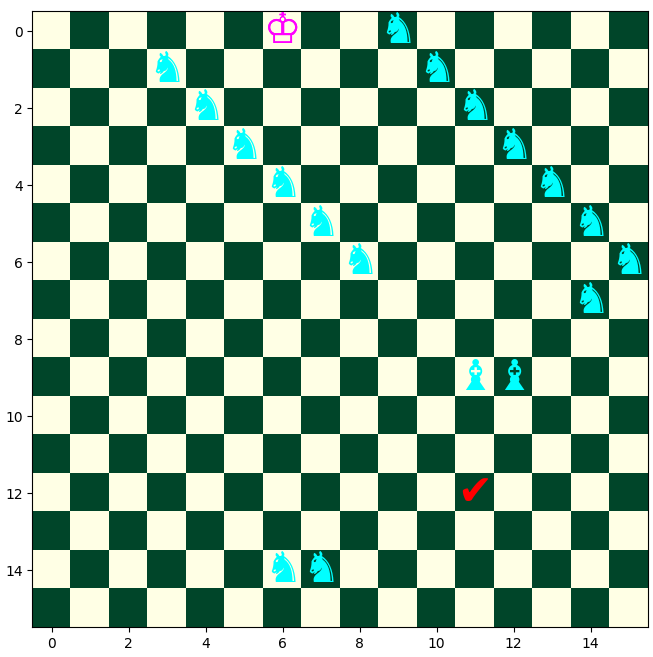

Estas son las 3 instancias con solución que proponemos:

In [ ]:
#Estructuras para almacenamiento de soluciones
datos_tabla = []
soluciones_BFS=[]
soluciones_DFS=[]
soluciones_A_SH=[]
soluciones_A_M=[]
soluciones_A_C=[]

#Configuracion de 3 escenarios (instancias)
casos = [
    {
        "nombre": "Fácil",
        "start_state": (8, 4),
        "alfiles": [(9, 4)],
        "torres": [(12, 5)],
        "caballos": [(8, 8), (12, 3)],
        "goal": (1, 0)
    },
    {
        "nombre": "Medio",
        "start_state": (6, 0),
        "alfiles": [(13, 9), (7, 5), (4, 10), (6, 4)],
        "torres": [(13, 3), (3, 12), (3,8), (5, 15)],
        "caballos": [(8, 8), (12, 3), (0, 0), (9, 12)],
        "goal": (15, 14)
    },
    {
        "nombre": "Difícil",
        "start_state": (1, 4),
        "alfiles": [(13, 9), (7, 5), (4, 10), (5,1)],
        "torres": [(13, 3), (0, 14), (15,1), (10,15)],
        "caballos": [(8, 8), (11, 3), (0, 0), (10, 12)],
        "goal": (12, 2)
    }
]

for c in casos:
    #Inicializamos el nodo raiz y extraemos los datos de la instancia actual
    start = sp.node(c['start_state'], depth=0, parent=None)
    alfiles = c['alfiles']
    torres = c['torres']
    caballos = c['caballos']
    goal = c['goal']

    #Verificar que la meta no este en jaque
    if esta_amenazada(goal[0], goal[1], set(alfiles + torres + caballos)):
        print("El rey no puede llegar a la meta porque está en jaque")
        continue

    #Busqueda en anchura (BFS)
    bfs = sp.TreeSearch(start, sucesor, meta, strategy="bfs")
    tb = time.time()
    r1 = bfs.find(max_iter=256)
    tf = time.time()
    tiempo_bfs = tf - tb
    if r1 is None:
      print("No se encontró una solución. Instancia:", c['nombre'])
    else:
      soluciones_BFS.append(r1)

    #Busqueda en profundidad (DFS)
    dfs = sp.TreeSearch(start, sucesor, meta, strategy="dfs")
    td = time.time()
    r2 = dfs.find(max_iter=256)
    tf = time.time()
    tiempo_dfs = tf - td
    if r2 is None:
      print("No se encontró una solución. Instancia:", c['nombre'])
    else:
      soluciones_DFS.append(r2)

    #Busqueda de costo uniforme (A* sin heuristica)
    bas=sp.TreeSearch(start, sucesor, meta, strategy="a*")
    tbas = time.time()
    r3 = bas.find(max_iter=256)
    tfbas = time.time()
    tiempo_bas = tfbas - tbas
    if r3 is None:
      print("No se encontró una solución. Instancia:", c['nombre'])
    else:
      soluciones_A_SH.append(r3)

    #Busqueda con heuritica Manhattan
    bas2 = sp.TreeSearch(start, sucesor, meta, strategy="a*", heuristic=manhatthan)
    tbas2 = time.time()
    r4 = bas2.find(max_iter=256)
    tfbas2 = time.time()
    tiempo_bas2 = tfbas2 - tbas2
    if r4 is None:
      print("No se encontró una solución. Instancia:", c['nombre'])
    else:
      soluciones_A_M.append(r4)

    #Busqueda con heuritica Chebyshev
    bas3=sp.TreeSearch(start, sucesor, meta, strategy="a*", heuristic=chebyshev)
    tbas3 = time.time()
    r5 = bas3.find(max_iter=256)
    tfbas3 = time.time()
    tiempo_bas3 = tfbas3 - tbas3
    if r5 is None:
      print("No se encontró una solución. Instancia:", c['nombre'])
    else:
      soluciones_A_C.append(r5)

    #Banderas para identificar instancias inconclusas
    easy = False
    medium = False
    hard = False
    if r1 is None or r2 is None or r3 is None or r4 is None or r5 is None:
      if c['nombre'] == "Fácil":
        easy = True
      elif c['nombre'] == "Medio":
        medium = True
      elif c['nombre'] == "Difícil":
        hard = True
      continue

    #Extraemos los nodos expandidos, tiempo de ejecucion, longitud y costo de cada solucion
    datos_tabla.append({"Instancia": c['nombre'], "Estrategia": "BFS", "Nodos expandidos": bfs.iterations, "Tiempo (s)": tiempo_bfs, "Longitud": len(r1.getPath())-1, "Costo": r1.cost})
    datos_tabla.append({"Instancia": c['nombre'], "Estrategia": "DFS", "Nodos expandidos": dfs.iterations, "Tiempo (s)": tiempo_dfs, "Longitud": len(r2.getPath())-1, "Costo": r2.cost})
    datos_tabla.append({"Instancia": c['nombre'], "Estrategia": "A* (Sin heurística)", "Nodos expandidos": bas.iterations, "Tiempo (s)": tiempo_bas, "Longitud": len(r3.getPath())-1, "Costo": r3.cost})
    datos_tabla.append({"Instancia": c['nombre'], "Estrategia": "A* (Manhatthan)", "Nodos expandidos": bas2.iterations, "Tiempo (s)": tiempo_bas2, "Longitud": len(r4.getPath())-1, "Costo": r4.cost})
    datos_tabla.append({"Instancia": c['nombre'], "Estrategia": "A* (Chevishev)", "Nodos expandidos": bas3.iterations, "Tiempo (s)": tiempo_bas3, "Longitud": len(r5.getPath())-1, "Costo": r5.cost})

tabla_comparativa = pd.DataFrame(datos_tabla)
tabla_comparativa

,Instancia,Estrategia,Nodos expandidos,Tiempo (s),Longitud,Costo
0,Fácil,BFS,39,0.016448,7,7
1,Fácil,DFS,28,0.013405,21,21
2,Fácil,A* (Sin heurística),41,0.025142,7,7
3,Fácil,A* (Manhatthan),16,0.006132,7,7
4,Fácil,A* (Chevishev),16,0.011041,7,7
5,Medio,BFS,54,0.026587,14,14
6,Medio,DFS,15,0.006378,15,15
7,Medio,A* (Sin heurística),54,0.035372,14,14
8,Medio,A* (Manhatthan),34,0.030622,14,14
9,Medio,A* (Chevishev),22,0.014711,14,14


# Verificación de Correctitud
*¿La longitud de A* coincide con BFS?*

Si, aunque tengan la misma longitud BFS puede haber expandidos más nodos pero encontrando el camino con el menor número de movimientos posible mientras que A* orienta la búsqueda a la meta expandiendo menos nodos.  

Como podemos observar el número de movimientos en las soluciones halladas, con excepción de DFS, suelen tener la misma longitud. Por ello conviene revisar otros dos parámetros: el número de nodos expandidos y la cantidad de tiempo que le toma al algoritmo hallar la solución.

Para todas las instancias el caso a vencer es cuando la heurística vale 0, ya que este nos da el mayor número de nodos expandidos y es la referencia de que nuestra heurística propuesta realmente aporte a la solución.

---

En la tabla comparativa podemos observar que el comportamiento de los algoritmos es el esperable: BFS explora mayor número de nodos pero encuentra una solución más corta, contrario al comportamiento de DFS.

Por otro lado, el algoritmo de A*, si tiene una heurística bien elegida, tiende a ser el mejor algoritmo en número de nodos expandidos y movimientos.

En la instancia difícil, todos los algoritmos expanden prácticamente los mismos nodos. Esto se debe a que la heurística intenta forzar la solución, buscando ir en línea recta hacia la meta pero debido a que existen múltiples líneas de obstáculos obligando a los algoritmos a regresar hasta el último nodo expandido y explorar la totalidad de las casillas transitables.

En cuestión de tiempo, al trabajar con un espacio de estados pequeños tenemos diferencias ínfimas, aunque en general fue DFS quien halló una solución primero.


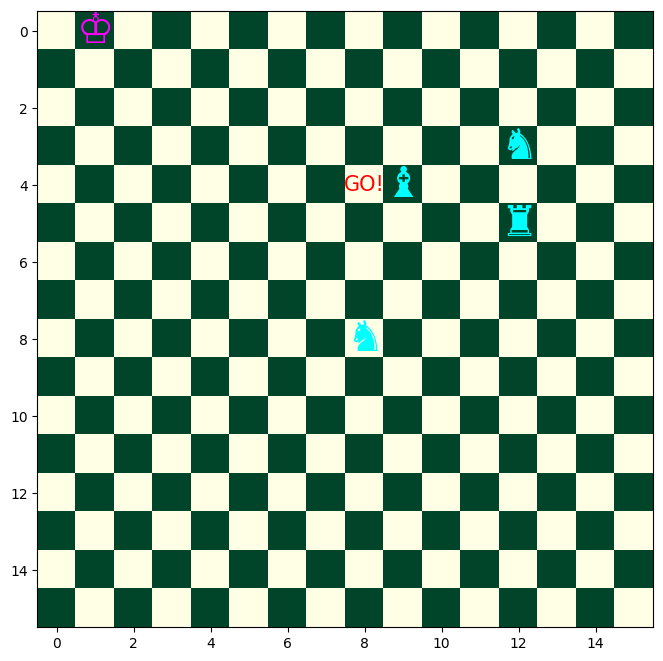

In [ ]:
#Esta sección de código nos ayuda a animar algún camino recorrido por el rey para llegar a la meta en alguna de las instancias y para algún algoritmo de búsqueda.
#Use soluciones_BFS=[] para animar caminos BFS
#Use soluciones_DFS=[] para animar caminos DFS
#Use soluciones_A_SH=[] para animar caminos A* sin heurística
#Use soluciones_A_M=[] para animar caminos A* con heurística Manhatthan modificada
#Use soluciones_A_C=[] para animar caminos A* con heurística Chevishev
#Use un valor de op=0 para animar la instancia facil, un valor de op=1 para la media y un op=2 para la dificil
op = 0
if easy == True:
  if op != 0:
    animar_camino(soluciones_A_C[op], casos[op]["alfiles"], casos[op]["torres"], casos[op]["caballos"])
  else:
    print("No se encontró solución")
elif medium == True:
  if op != 1:
    animar_camino(soluciones_A_C[op], casos[op]["alfiles"], casos[op]["torres"], casos[op]["caballos"])
  else:
    print("No se encontró solución")
elif hard == True:
  if op != 2:
    animar_camino(soluciones_A_C[op], casos[op]["alfiles"], casos[op]["torres"], casos[op]["caballos"])
  else:
    print("No se encontró solución")
else:
  animar_camino(soluciones_A_C[op], casos[op]["alfiles"], casos[op]["torres"], casos[op]["caballos"])


# Análisis de Heurística

```
def chebyshev(*nodos):
    nodo = nodos[0]
    x = nodo.state[0]
    y = nodo.state[1]
    maximo = max(abs(goal[0]-x), abs(goal[1]-y))
    return maximo
```



*¿Qué mide tu heurística y por qué es una estimación razonable del trabajo que falta?*

La heurística de distancia de Chebyshev mide el número mínimo de movimientos que le tomaría a un rey de ajedrez desplazarse desde una posición actual hasta una posición objetivo en el tablero, considerando que puede moverse una casilla a la vez en cualquier dirección.

Para este problema específico, es una estimación sumamente razonable y admisible por las siguientes razones:


*   En un escenario sin obstáculos esta distancia coincide exactamente con el número real de movimientos necesarios para que el rey alcance la meta.
*   Cuando hay rivales en el tablero, los obstáculos únicamente pueden bloquear o alargar el camino, obligando al rey a dar rodeos. Por lo tanto, el coste real siempre será mayor o igual a la distancia de Chebyshev.
* Dado que la heurística calcula el caso óptimo sin obstáculos, nunca sobreestima el coste real del trayecto restante.  

---
*¿Es admisible? Da un argumento o un contraejemplo. El argumento típico es de relajación: si ignoro la restricción X, el problema se resuelve en exactamente h(n) pasos, y el problema real no puede ser más fácil.*

Si, es admisible.
Si consideramos un escenario sin enemigos la distancia Chebyshev nos da exactamente el número de movimientos en los cuales el rey puede alcanzar la meta, en el mejor caso posible de un tablero con enemigos (estos no pueden atacar el camino óptimo para llegar a la meta) la cantidad de movimientos será igual a la distancia Chevishev, no es posible que sea menor, y por tanto la heurística cumple con la condición de admisibilidad.


---
*¿Cuánto ayuda? Compárala contra h(n)=0 en nodos expandidos, sobre las tres instancias.*

Para la instancia fácil la heurística ayuda significativamente, reduciendo los nodos expandidos a menos de la mitad, ya que guía el camino directamente hacia la meta sin explorar tantas direcciones innecesarias.

Para la instancia media se mantiene la eficiencia, la heurística vuelve a recortar la exploración a más de la mitad en comparación con h(n)=0.

Para la instancia difícil la mejora es prácticamente nula. Esto suele ocurrir en tableros donde la disposición de los obstáculos (enemigos) obliga al rey a realizar tantos rodeos que la distancia directa de Chebyshev pierde su eficacia predictiva local, comportándose casi igual que una búsqueda ciega en esa zona del espacio de estados.  


---

*Propón una segunda heurística (más débil o más fuerte) y compárala con la primera. Dos heurísticas correctas no valen lo mismo.*

Proponemos como segunda heurística el techo de la distancia Manhattan dividida a la mitad, es decir, la suma de las diferencias absolutas de las coordenadas X e Y dividida entre 2, aplicando la función techo para redondear hacia arriba.



```
def manhatthan(*nodos):
    nodo = nodos[0]
    x = nodo.state[0]
    y = nodo.state[1]
    total = math.ceil((abs(goal[0]-x) +abs(goal[1]-y) ) / 2)
    return total
```



Esta segunda heurística es más débil que la distancia de Chebyshev.
Debido a que la distancia de Chebyshev modela de forma exacta el movimiento en todas direcciones del rey, proporciona una cantidad de movimientos igual al coste real sin obstáculos. En contraste, la versión basada en Manhattan ajustada suele ofrecer estimaciones más bajas o menos precisas en varios puntos del tablero.

Al ser una heurística más débil, guía con menor precisión al algoritmo A*, lo que se traduciría en la expansión de una mayor cantidad de nodos en comparación con el uso exclusivo de Chebyshev, manteniéndose de todos modos dentro de la admisibilidad al nunca sobreestimar el coste real.

A partir de los datos obtenidos, se aprecia que Chebyshev por lo regular expande una menor cantidad de nodos (o, en el peor de los casos, una cantidad equivalente) en comparación con la alternativa basada en Manhattan. Aunque el rendimiento específico varía según la disposición de cada instancia, la heurística de Chebyshev presenta ventaja al guiar la búsqueda con mayor precisión.

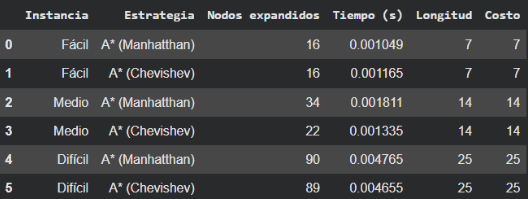

# **Conclusiones.**

### **¿Qué estrategia ganó y por qué?**

Al evaluar de forma integral todas las estrategias analizadas (BFS, DFS, A* con Manhattan y A* con Chebyshev), la estrategia ganadora es A* con la heurística de Chebyshev, ya que logra un equilibrio sobresaliente entre la optimalidad y la eficiencia. A diferencia de algoritmos como BFS, que opera sin una guía direccional y requiere un esfuerzo computacional mucho mayor (llegando a expandir hasta 54 nodos en la instancia media para alcanzar la misma longitud de camino óptimo de 14), y de la búsqueda en profundidad (DFS), la cual sacrifica por completo la calidad de la solución generando rutas ineficientes de mayor costo (como una longitud de 21 frente a los 7 pasos óptimos en la instancia fácil), Chebyshev maximiza el rendimiento del algoritmo. Si bien A* con Manhattan es una alternativa válida, la distancia de Chebyshev modela con mayor exactitud la cinemática del movimiento del rey en todas direcciones, lo que se refleja claramente en la instancia media al reducir la exploración a 22 nodos frente a los 34 de Manhattan sin comprometer el costo óptimo. En definitiva, esta combinación acota el espacio de búsqueda y consolida a Chebyshev como la opción más robusta y eficiente.

### **¿Qué harías distinto?**

Lo que haríamos distinto sería probar con enemigos en movimiento, esto haría que nuestro espacio de búsqueda aumentara muchísimo ya que el estado sería definido no solo por la posición del rey sino también por la posición de todas las piezas rivales.

# Referencias

GeeksforGeeks. (2025, 26 julio). Chebyshev distance. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/chebyshev-distance/

Datacamo.com (2024, 5 septiembre). https://www.datacamp.com/tutorial/chebyshev-distance

Ortiz Béjar José (2018).baile[Codigo Fuente].GitHub.https://github.com/kyriox/baile/tree/master

Gerardo Govany Padiula Miranda.

A lo largo de todo el proyecto los 3 participantes colaboramos de igual forma, desde aportar ideas hasta implementarlas, particularmente considero que aporté más a la hora de proponer y buscar nuevas heurísticas admisibles.

Pedro Fernandez Jimenez.

Durante el desarrollo del proyecto participe activamente en todos los ambitos junto con mis compañeros pero especialmente en el analisis de casos de prueba para las configuraciones del tablero.

Sonia Aylin Castro Cedeño.

Para este proyecto trabajamos los tres integrantes en equipo y de forma muy colaborativa en cada una de las etapas, desde la planeación hasta la implementación final. Considero que participe un poco más a la hora de organizar las tablas de resultados y animar el camino del rey.